In [1]:
import pickle
import torch
import numpy as np

with open('./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/sample1/args.pickle', 'rb') as f:
    args = pickle.load(f)

In [2]:
print(args)

Namespace(debug=0, epochs=1000, seed=1, device='cuda', parallel=None, resume=None, need_regularization=False, name='2025-06-09_16-04-51', project='amazon_cross_diffusion_discrete_boxcox_200_tgt_len_20', eval_every=50, check_every=2, log_tb=True, log_home='.', eval_num_samples=5, distance_del_cost=[0.05, 0.5, 1, 1.5, 2, 3, 4], trans_cost=1.0, dataset='amazon', dataset_dir='./data/amazon', validation=True, tgt_len=20, boxcox=True, feature=True, batch_size=1024, num_workers=1, pin_memory=False, diffusion_steps=200, transformer_dim=32, transformer_heads=2, num_encoder_layers=1, dim_feedforward=64, num_decoder_layers=1, optimizer='adam', lr=0.0005, warmup=None, update_freq=1, momentum=0.9, momentum_sqr=0.999, gamma=0.99, scheduler='cosanneal', grad_norm=False, no_grad_norm=True, model=None, num_samples=1, filter=False, num_seqs_analysis=40, train_lambda_boxcox=np.float64(0.7389405452942325), scale=tensor(22.9253), train_mean=tensor(0.5345), train_std=tensor(0.3363), train_min=tensor(0.0100)

In [3]:
args.seed = 1

In [4]:
args.log_path = './log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51'

In [5]:
path_samples='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200', 
path_samples_result='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/result.txt', 
path_samples_dt='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_dt.pt', 
path_samples_chain_dt='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_chain_dt.pt', 
path_samples_type='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_type.pt', 
path_samples_chain_type='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/samples_type.pt', 
path_gt_dt='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/gt_dt.pt', 
path_gt_type='./log/flow/amazon/cross_diffusion_discrete_boxcox_200_tgt_len_20/cosanneal/2025-06-09_16-04-51/samples/sample_ep1000_s1_num_s_1_num_steps_200/gt_type.pt'

In [ ]:
import torch



# samples_dt_20 = torch.load('./nullsamples/amazon20/1_20/samples_dt.pt')
# samples_type_20 = torch.load('./nullsamples/amazon20/1_20/samples_type.pt')
# samples_dt_40 = torch.load('./nullsamples/amazon20/21_40/samples_dt.pt')
# samples_type_40 = torch.load('./nullsamples/amazon20/21_40/samples_type.pt')
# samples_dt_60 = torch.load('./nullsamples/amazon20/41_60/samples_dt.pt')
# samples_type_60 = torch.load('./nullsamples/amazon20/41_60/samples_type.pt')
# samples_dt_80 = torch.load('./nullsamples/amazon20/61_80/samples_dt.pt')
# samples_type_80 = torch.load('./nullsamples/amazon20/61_80/samples_type.pt')
# samples_dt_100 = torch.load('./nullsamples/amazon20/81_100/samples_dt.pt')
# samples_type_100 = torch.load('./nullsamples/amazon20/81_100/samples_type.pt')

In [51]:
len(samples_dt_80[0])

20

In [8]:
with open('./data/amazon/test.pkl', 'rb') as f:
    test = pickle.load(f)

In [115]:
test['dim_process']

16

In [54]:
N = samples_dt_20.size(0)          # 500
sequences = []
print(N)
for i in range(N):
    dt_part1  = samples_dt_20[i, :, 0].tolist()   # 20
    typ_part1 = samples_type_20[i, :, 0].tolist()

    # dt_part2  = samples_dt_40[i, :, 0].tolist()   # 20
    # typ_part2 = samples_type_40[i, :, 0].tolist()

    # dt_part3  = samples_dt_60[i, :, 0].tolist()   # 20
    # typ_part3 = samples_type_60[i, :, 0].tolist()

    # dt_part4  = samples_dt_80[i, :, 0].tolist()   # 20
    # typ_part4 = samples_type_80[i, :, 0].tolist()

    # dt_part5  = samples_dt_100[i, :, 0].tolist()   # 20
    # typ_part5 = samples_type_100[i, :, 0].tolist()

    dt_all  = dt_part1 
    # + dt_part2  + dt_part3  + dt_part4  +  dt_part5             # 40
    typ_all = typ_part1 
    # + typ_part2 + typ_part3 +  typ_part4  +   typ_part5

    seq, t_cum = [], 0.0
    for d, k in zip(dt_all, typ_all):
        t_cum += d
        seq.append({
            'type_event': int(k),
            'time_since_last_event': float(d),
            'time_since_start': t_cum
        })

    pad = 20                                      
    seq.extend([{
        'type_event': 0,
        'time_since_last_event': 0,
        'time_since_start': 0
    } for _ in range(pad)])

    sequences.append(seq)                    

dataset = {
    'dim_process': 1,
    'test': sequences
}

with open('test.pkl', 'wb') as f:
    pickle.dump(dataset, f)


500


In [111]:
len(dataset['generated'][0])

100

In [131]:
import pickle
import torch

# data = 'nonstat_renewal'

# with open(f'./data/synthetic/{data}/train.pkl', 'rb') as f:
#     train_data = pickle.load(f)
# with open(f'./data/synthetic/{data}/test.pkl', 'rb') as f:
#     test_data = pickle.load(f)
# with open(f'./data/synthetic/{data}/dev.pkl', 'rb') as f:
#     dev_data = pickle.load(f)

data = 'taxi'
with open(f'./data/{data}/train.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open(f'./data/{data}/test.pkl', 'rb') as f:
    test_data = pickle.load(f)
with open(f'./data/{data}/dev.pkl', 'rb') as f:
    dev_data = pickle.load(f)

print(len(train_data['train']))
print(len(test_data['test']))
print(len(dev_data['dev']))

1400
400
200


In [132]:
with open(f'./nullsamples/taxi20/generated_taxi20_40.pkl', 'rb') as f:
    dataset = pickle.load(f)

print(len(dataset['generated']))

1024


In [90]:
print(dataset['generated'][2][-5])

{'type_event': 0, 'time_since_last_event': 10.497302921396477, 'time_since_start': 1652.2161910340246}


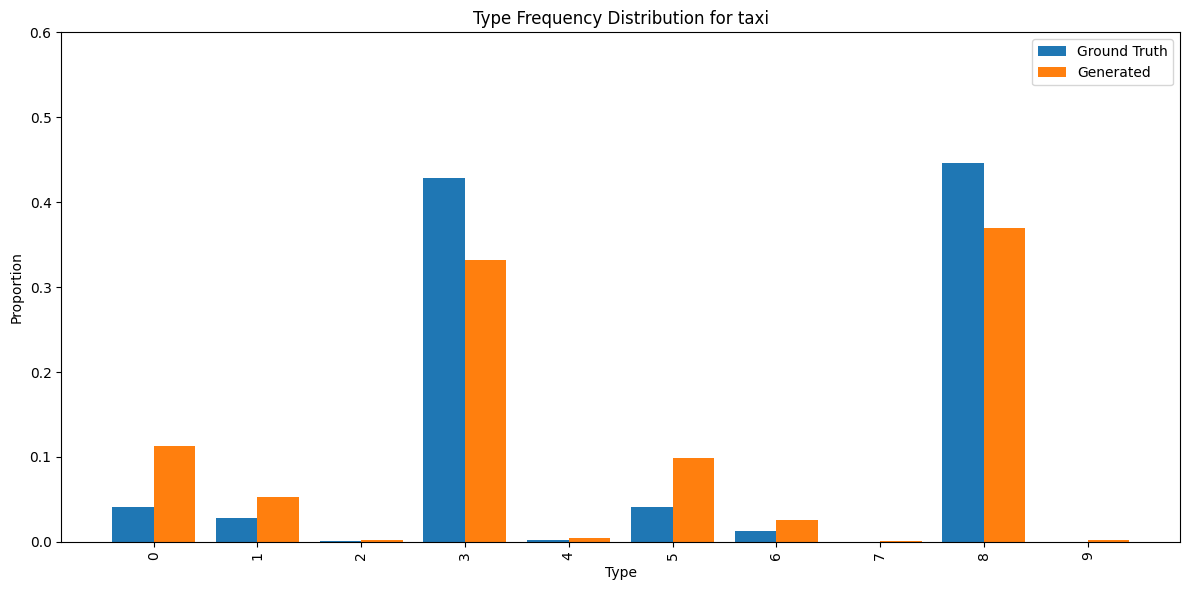

In [134]:
import numpy as np
from collections import Counter
import matplotlib.pyplot as plt

pred_types = []
for i in range(len(dataset['generated'])):
    for j in range(len(dataset['generated'][i])):
        pred_types.append(dataset['generated'][i][j]['type_event'])

gt_types = []
for i in range(len(train_data['train'][:1024])):
    for j in range(len(train_data['train'][i])):
        gt_types.append(train_data['train'][i][j]['type_event'])
# for i in range(len(test_data['test'])):
#     for j in range(len(test_data['test'][i])):
#         gt_types.append(test_data['test'][i][j]['type_event'])
# for i in range(len(dev_data['dev'])):
#     for j in range(len(dev_data['dev'][i])):
#         gt_types.append(dev_data['dev'][i][j]['type_event'])

def type_visualise():
    count1 = Counter(gt_types)
    count2 = Counter(pred_types)

    total1 = sum(count1.values())
    total2 = sum(count2.values())

    all_keys = sorted(set(count1.keys()) | set(count2.keys()))
    freq1 = [count1.get(k, 0) / total1 for k in all_keys]
    freq2 = [count2.get(k, 0) / total2 for k in all_keys]

    x = np.arange(len(all_keys))
    width = 0.4

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar(x - width / 2, freq1, width=width, label='Ground Truth')
    ax.bar(x + width / 2, freq2, width=width, label='Generated')

    ax.set_xticks(x)
    ax.set_xticklabels(all_keys, rotation=90)
    ax.set_xlabel('Type')
    ax.set_ylabel('Proportion')
    ax.set_title(f'Type Frequency Distribution for {data}')
    ax.set_ylim(0, 0.6)
    ax.legend()

    plt.tight_layout()
    plt.show()

type_visualise()


In [ ]:
for s in train_data['train'][:10]:
    print(s[0]['time_since_start'],'-----',s[-1]['time_since_start'], '-------', len(s))
print("XXXXXXXXXXXx")
for s in dataset['test'][:10]:
    print(s[0]['time_since_start'],'-----',s[-1]['time_since_start'])

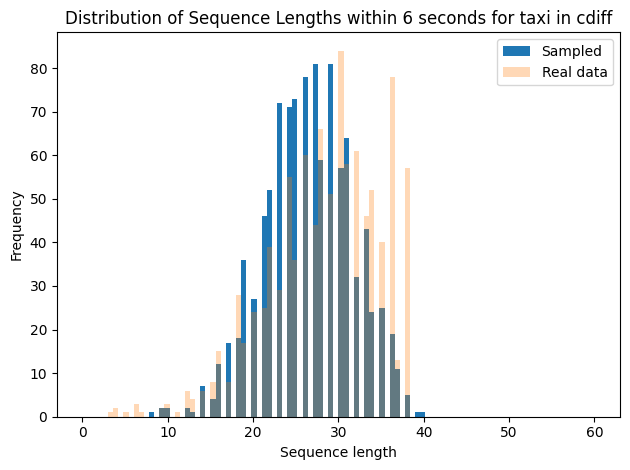

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


t_max = 6

# counts_gt = [sum(1 for e in seq if e['time_since_start'] < t_max) for seq in test_data['test']]
counts_gt = (
    [sum(1 for e in seq if e['time_since_start'] < t_max) for seq in train_data['train'][:1024]]
    # [sum(1 for e in seq if e['time_since_start'] < t_max) for seq in test_data['test']] +
    # [sum(1 for e in seq if e['time_since_start'] < t_max) for seq in dev_data['dev']]
)

counts_pred = [sum(1 for e in seq if e['time_since_start'] < t_max) for seq in dataset['generated']]

# counts_pred = [c for c in counts_pred if c > 1]

plt.hist(counts_pred, bins=100, label='Sampled', density=False, range=(0, 100))
plt.hist(counts_gt, bins=100, alpha=0.3, label='Real data', density=False, range=(0, 100))
plt.xlabel("Sequence length")
plt.ylabel("Frequency")
plt.title(f"Distribution of Sequence Lengths within {t_max} seconds for {data} in cdiff")
plt.legend()
plt.tight_layout()
plt.show()


In [109]:
m = 0
seq_last_time = []
print(len(dataset['generated']))

for i in range(500):
    # print(dataset['generated'][i])
    # print("For sequence:",i,"",dataset['generated'][i][-1]['time_since_start'])
    seq_last_time.append(dataset['generated'][i][-1]['time_since_start'])
    m = max(dataset['generated'][i][-1]['time_since_start'], m)

500


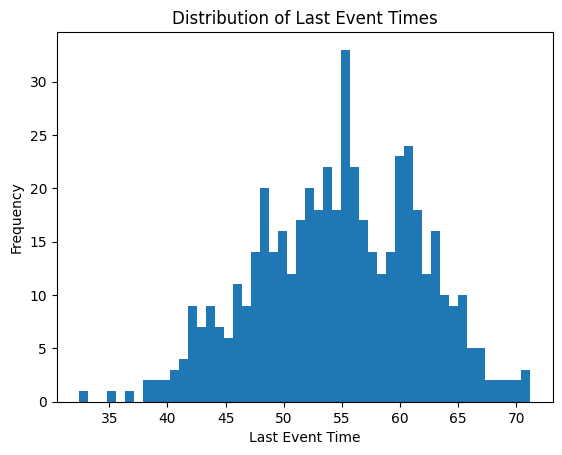

In [110]:
import matplotlib.pyplot as plt
plt.hist(seq_last_time, bins=50)
plt.xlabel("Last Event Time")
plt.ylabel("Frequency")
plt.title("Distribution of Last Event Times")
plt.show()

In [19]:
import os

base_path = './nullsamples/amazon88'
gt_dt = torch.load(os.path.join(base_path, 'gt_dt.pt'))
gt_type = torch.load(os.path.join(base_path, 'gt_type.pt'))

with open('./data/amazon/train.pkl', 'rb') as f:
    train_data = pickle.load(f)
with open('./data/amazon/test.pkl', 'rb') as f:
    test_data = pickle.load(f)
with open('./data/amazon/dev.pkl', 'rb') as f:
    dev_data = pickle.load(f)

In [37]:
# Length of sequences:
seq_lens = []
gt_seq_last_time = []
for i in range(len(train_data['train'])):
  seq_lens.append(len(train_data['train'][i]))
#   gt_seq_last_time.append(train_data['train'][i][-1]['time_since_start'])
for i in range(len(test_data['test'])):
  seq_lens.append(len(test_data['test'][i]))
  gt_seq_last_time.append(test_data['test'][i][-1]['time_since_start'])
for i in range(len(dev_data['dev'])):
  seq_lens.append(len(dev_data['dev'][i]))
#   gt_seq_last_time.append(dev_data['dev'][i][-1]['time_since_start'])

In [41]:
mean_len = np.mean(seq_lens)
std_len = np.std(seq_lens)

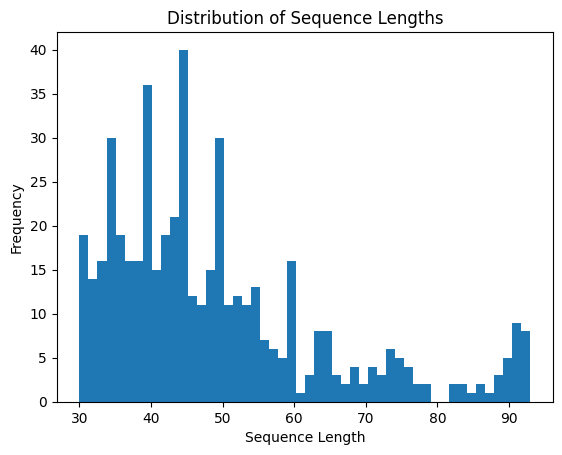

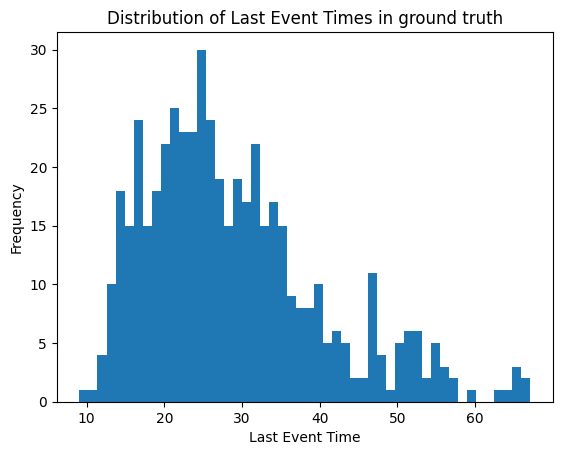

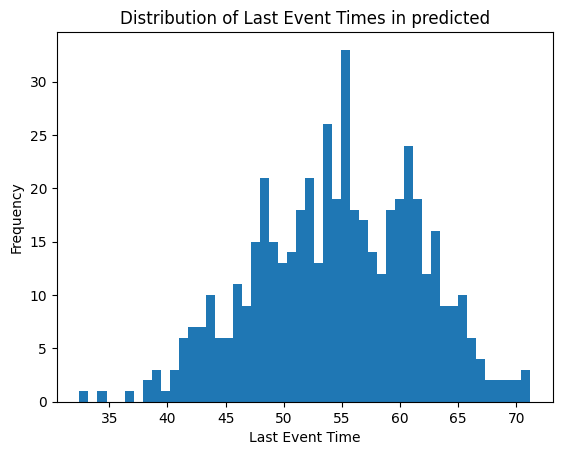

In [34]:
import matplotlib.pyplot as plt

# Histogram of sequence lengths
plt.hist(seq_lens, bins=50)
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.title("Distribution of Sequence Lengths")
plt.show()

# Histogram of last event times
plt.hist(gt_seq_last_time, bins=50)
plt.xlabel("Last Event Time")
plt.ylabel("Frequency")
plt.title("Distribution of Last Event Times in ground truth")
plt.show()


plt.hist(seq_last_time, bins=50)
plt.xlabel("Last Event Time")
plt.ylabel("Frequency")
plt.title("Distribution of Last Event Times in predicted")
plt.show()

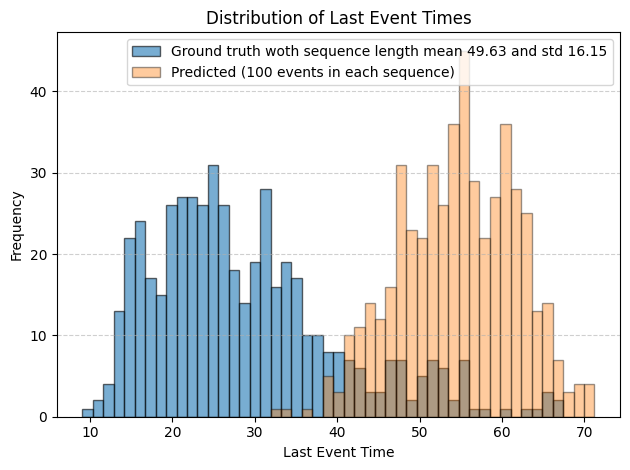

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

bins = np.linspace(min(min(gt_seq_last_time), min(seq_last_time)),
                   max(max(gt_seq_last_time), max(seq_last_time)),
                   50)

plt.hist(gt_seq_last_time, bins=bins, alpha=0.6, label=f"Ground truth with sequence length mean {round(mean_len,2)} and std {round(std_len,2)}", edgecolor='black')
plt.hist(seq_last_time,    bins=bins, alpha=0.4, label='Predicted (100 events in each sequence)',    edgecolor='black')
plt.xlabel('Last Event Time')
plt.ylabel('Frequency')
plt.title('Distribution of Last Event Times')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


###### FOR SEQUENCE 1: ######

Number of events in original sequence: 81
Last time stamp:  51.82551956176758
Ground truth type:
 1 1 4 1 1 0 15 1 0 0 4 1 2 1 1 1 1 1 0 0 0 2 1 1 0 1 0 0 1 0 2 2 1 2 0 1 0 2 3 0 2 1 0 0 2 0 0 0 1 1 1 2 2 4 2 1 2 2 0 1 1 0 3 0 1 1 1 2 0 0 1 3 0 0 1 1 1 1 1 0 1 0
Ground truth interarrival time:
 0.0113 0.7328 0.7203 0.7908 0.7496 0.7706 0.7451 0.7133 0.7123 0.7485 0.7126 0.7591 0.7067 0.7298 0.7048 0.7859 0.7877 0.7891 0.7750 0.7944 0.7293 0.7936 0.7260 0.7133 0.7515 0.7715 0.7555 0.7536 0.0108 0.7145 0.7736 0.7848 0.7873 0.7083 0.7555 0.0139 0.7413 0.0117 0.7379 0.7468 0.0148 0.0131 0.7835 0.7360 0.7133 0.7944 0.7246 0.7106 0.7267 0.7591 0.7741 0.7017 0.7137 0.0139 0.7950 0.0130 0.7054 0.7722 0.7966 0.7872 0.7956 0.7673 0.0150 0.7800 0.0111 0.7216 0.7597 0.0116 0.7087 0.7566 0.7359 0.0147 0.0101 0.7302 0.7453 0.7128 0.7380 0.7861 0.7488 0.7683 0.7044 0.7347
Ground truth arrival time:
 0.0113 0.7441 1.4644 2.2551 3.0047 3.7753 4.5204 5.2337 5.9460 6.6945 7

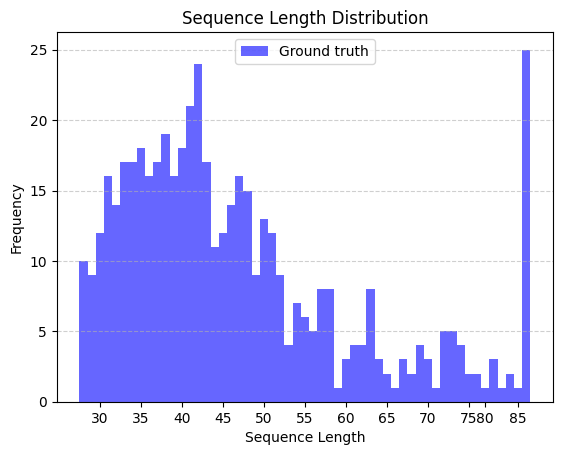

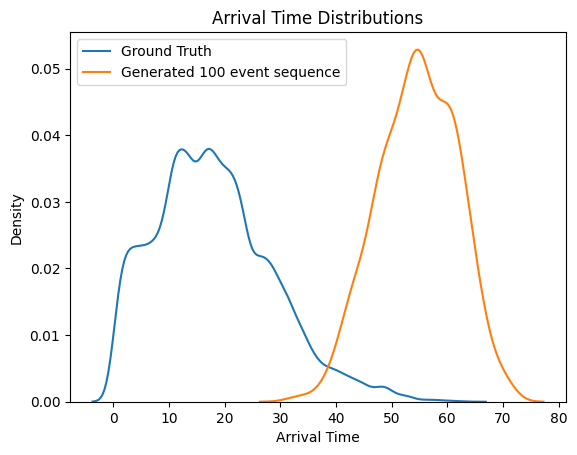

In [ ]:
import seaborn as sns
from collections import Counter

def arrival_time_visual():
    gt_arrival = torch.cumsum(gt_dt, dim=1).flatten().tolist()

    fig, ax = plt.subplots()
    sns.kdeplot(gt_arrival, label="Ground Truth", bw_adjust=1, ax=ax)
    sns.kdeplot(seq_last_time, label="Generated 100 event sequence", bw_adjust=1, ax=ax)
    
    ax.set_xlabel("Arrival Time")
    ax.set_ylabel("Density")
    ax.set_title("Arrival Time Distributions")
    ax.legend()

    plt.show()
arrival_time_visual()

In [ ]:
x = []
for s in train_data['train']:
    print(s[0]['time_since_start'], s[-1]['time_since_start'])
    x.append(s[0]['time_since_start'])
print(min(x))

In [ ]:
for s in dataset['generated']:
    print(s[0]['time_since_start'],'-----',s[-1]['time_since_start'])